### [Success DNA] 등급별 성적 및 전체 평균 합격선
               sentiment  velocity  value_score  stability  tail_ratio
high_high       696.2515    8.2931     110.9716     8.4503      0.4082
high_mid        549.2768    1.3979       0.0130     9.3910      0.3360
mid_high        459.9542    0.3116     127.0021    11.3986      0.4033
SUCCESS_TOTAL   566.7292    3.8235     111.6965    10.0068      0.4009


<Figure size 1400x700 with 0 Axes>

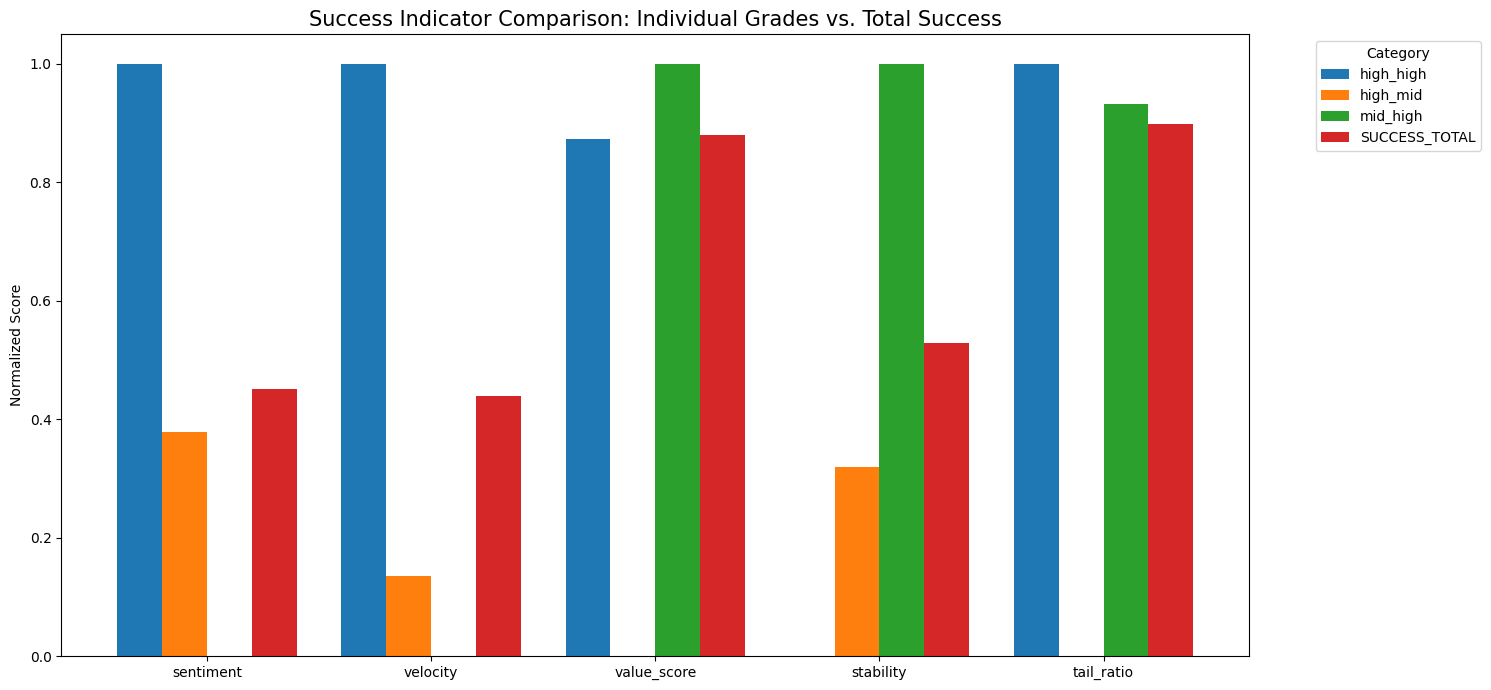

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드 (전달해주신 경로 적용)
base_path = '../../../../data/preprocessed/'
games_df = pd.read_csv(f'{base_path}steam_indie_games_graded.csv')
hist_df = pd.read_csv(f'{base_path}steam_indie_review_histogram.csv')

# 날짜 형식 변환
games_df['release_date'] = pd.to_datetime(games_df['release_date'])
hist_df['date'] = pd.to_datetime(hist_df['date'])

# 2. 롱테일 지수(Tail Ratio) 및 시그널 지표 계산
# 중복 컬럼(release_date) 충돌 방지를 위해 suffixes 설정
merged_hist = pd.merge(hist_df, games_df[['appid', 'release_date']], on='appid', suffixes=('_hist', ''))
merged_hist['days_after_release'] = (merged_hist['date'] - merged_hist['release_date']).dt.days

# 출시 90일(M3) 기준 리뷰 유입량 분리 (히스토그램의 recommendations_up 활용)
early_rev = merged_hist[merged_hist['days_after_release'] <= 90].groupby('appid')['recommendations_up'].sum().reset_index(name='early_rev')
total_rev_hist = merged_hist.groupby('appid')['recommendations_up'].sum().reset_index(name='total_rev_hist')

tail_stats = pd.merge(total_rev_hist, early_rev, on='appid', how='left').fillna(0)
tail_stats['tail_ratio'] = (tail_stats['total_rev_hist'] - tail_stats['early_rev']) / tail_stats['total_rev_hist']
tail_stats['tail_ratio'] = tail_stats['tail_ratio'].replace([np.inf, -np.inf], 0).fillna(0).clip(0, 1)

# 게임 데이터에 병합 및 4대 시그널 생성
final_df = pd.merge(games_df, tail_stats[['appid', 'tail_ratio']], on='appid')

# 현재 시점(2026-05-04) 기준 지표 산출
curr_date = pd.to_datetime('2026-05-04')
final_df['velocity'] = final_df['total_reviews'] / (curr_date - final_df['release_date']).dt.days.clip(1)
final_df['sentiment'] = final_df['positive_rate'] * np.log1p(final_df['total_reviews'])
final_df['value_score'] = final_df['recommendations_total'].fillna(0) / (final_df['owners_lower'] + 1)
final_df['stability'] = final_df['positive_rate'] / (final_df['price'] + 1)

# 3. 흥행 집단(HH, HM, MH) 분석
target_grades = ['high_high', 'high_mid', 'mid_high']
success_group = final_df[final_df['performance_grade'].isin(target_grades)].copy()

features = ['sentiment', 'velocity', 'value_score', 'stability', 'tail_ratio']

# (1) 등급별 평균
grade_summary = success_group.groupby('performance_grade')[features].mean()

# (2) 흥행 집단 전체 통합 평균
combined_avg = pd.DataFrame(success_group[features].mean()).T
combined_avg.index = ['SUCCESS_TOTAL']

# 결과 통합
success_dna = pd.concat([grade_summary, combined_avg])

# 4. 결과 출력 및 시각화
pd.options.display.float_format = '{:.4f}'.format
print("### [Success DNA] 등급별 성적 및 전체 평균 합격선")
print(success_dna)

# 지표 간 차이를 보기 위한 정규화 시각화
plt.figure(figsize=(14, 7))
norm_dna = (success_dna - success_dna.min()) / (success_dna.max() - success_dna.min())
norm_dna.T.plot(kind='bar', figsize=(15, 7), rot=0, width=0.8, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
plt.title('Success Indicator Comparison: Individual Grades vs. Total Success', fontsize=15)
plt.ylabel('Normalized Score')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### [Success DNA] 전수 데이터(9692개) 기반 분석 결과
               velocity  sentiment  value_score  stability  tail_ratio
high_high     6612.0178    90.7134      74.7835    32.9912      0.5541
high_mid      3595.6868    75.9755      46.4530    39.3224      0.2960
mid_high       163.3306    90.8756     188.8922    45.8899      0.5298
SUCCESS_TOTAL 2134.3321    89.9977     134.2064    39.9486      0.5240


<Figure size 1400x700 with 0 Axes>

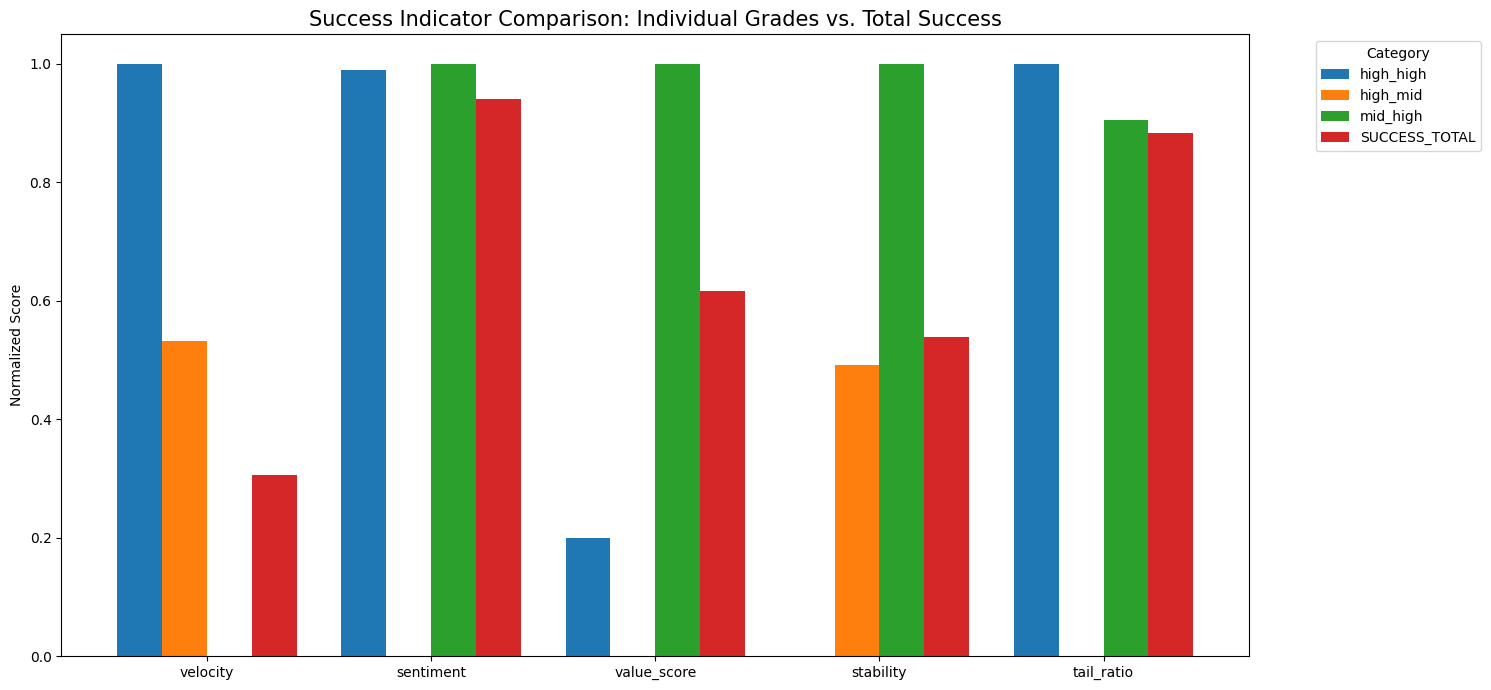

In [35]:
import pandas as pd
import numpy as np

base_path = '../../../../data/preprocessed/'
df_all = pd.read_csv(f'{base_path}steam_indie_games_graded.csv')
df_hist = pd.read_csv(f'{base_path}steam_indie_review_histogram.csv')

df_all.columns = df_all.columns.str.strip()
df_hist.columns = df_hist.columns.str.strip()

# 날짜 컬럼 전처리 및 타입 강제 변환
df_all['release_date'] = pd.to_datetime(df_all['release_date'], errors='coerce')
df_hist['date'] = pd.to_datetime(df_hist['date'], errors='coerce')

# 히스토그램 내 기존 release_date가 있다면 제거 후, df_all의 datetime 객체로 재병합 (TypeError 방지)
if 'release_date' in df_hist.columns:
    df_hist = df_hist.drop(columns=['release_date'])
df_hist = pd.merge(df_hist, df_all[['appid', 'release_date']], on='appid', how='inner')

# 🎯 [Step 1] 전수 데이터 기반 지표 (9,692개)
df_all['velocity'] = df_all['total_reviews']
df_all['sentiment'] = df_all['positive_rate']
df_all['value_score'] = df_all['recommendations_total'] / (df_all['owners_lower'] + 1)

# 🎯 [Step 2] 히스토그램 기반 지표 (200개 샘플)
df_hist['daily_pos_rate'] = (df_hist['recommendations_up'] / 
                            (df_hist['recommendations_up'] + df_hist['recommendations_down'] + 1e-6)) * 100
stability_stats = df_hist.groupby('appid')['daily_pos_rate'].std().reset_index(name='stability')

# Tail Ratio 계산 (91-365일 성장성)
df_hist['days_after_release'] = (df_hist['date'] - df_hist['release_date']).dt.days
df_hist['daily_total'] = df_hist['recommendations_up'] + df_hist['recommendations_down']

early_rev = df_hist[df_hist['days_after_release'] <= 90].groupby('appid')['daily_total'].sum().reset_index(name='rev_0_90')
mid_rev = df_hist[(df_hist['days_after_release'] > 90) & 
                  (df_hist['days_after_release'] <= 365)].groupby('appid')['daily_total'].sum().reset_index(name='rev_91_365')

tail_stats = pd.merge(early_rev, mid_rev, on='appid', how='left').fillna(0)
tail_stats['tail_ratio'] = tail_stats['rev_91_365'] / (tail_stats['rev_0_90'] + 1e-6)

# 🎯 [Step 3] 최종 병합 및 DNA 추출
final_df = pd.merge(df_all, tail_stats[['appid', 'tail_ratio']], on='appid', how='left')
final_df = pd.merge(final_df, stability_stats, on='appid', how='left')

target_grades = ['high_high', 'high_mid', 'mid_high']
features = ['velocity', 'sentiment', 'value_score', 'stability', 'tail_ratio']
success_group = final_df[final_df['performance_grade'].isin(target_grades)].copy()

success_dna = pd.concat([
    success_group.groupby('performance_grade')[features].mean(),
    pd.DataFrame(success_group[features].mean()).T.rename(index={0: 'SUCCESS_TOTAL'})
])

pd.options.display.float_format = '{:.4f}'.format
print(f"### [Success DNA] 전수 데이터({len(df_all)}개) 기반 분석 결과")
print(success_dna)

plt.figure(figsize=(14, 7))
norm_dna = (success_dna - success_dna.min()) / (success_dna.max() - success_dna.min())
norm_dna.T.plot(kind='bar', figsize=(15, 7), rot=0, width=0.8, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
plt.title('Success Indicator Comparison: Individual Grades vs. Total Success', fontsize=15)
plt.ylabel('Normalized Score')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### [Success DNA] 중앙값(Median) 기반 분석 결과
               velocity  sentiment  value_score  stability  tail_ratio
high_high     1547.0000    91.1798       0.0324    38.4652      0.4111
high_mid       867.5000    76.4131       0.0236    39.4204      0.3520
mid_high       116.0000    91.3793     155.0000    46.8062      0.4172
SUCCESS_TOTAL  223.0000    90.7407       0.0503    42.9992      0.4025


<Figure size 1400x700 with 0 Axes>

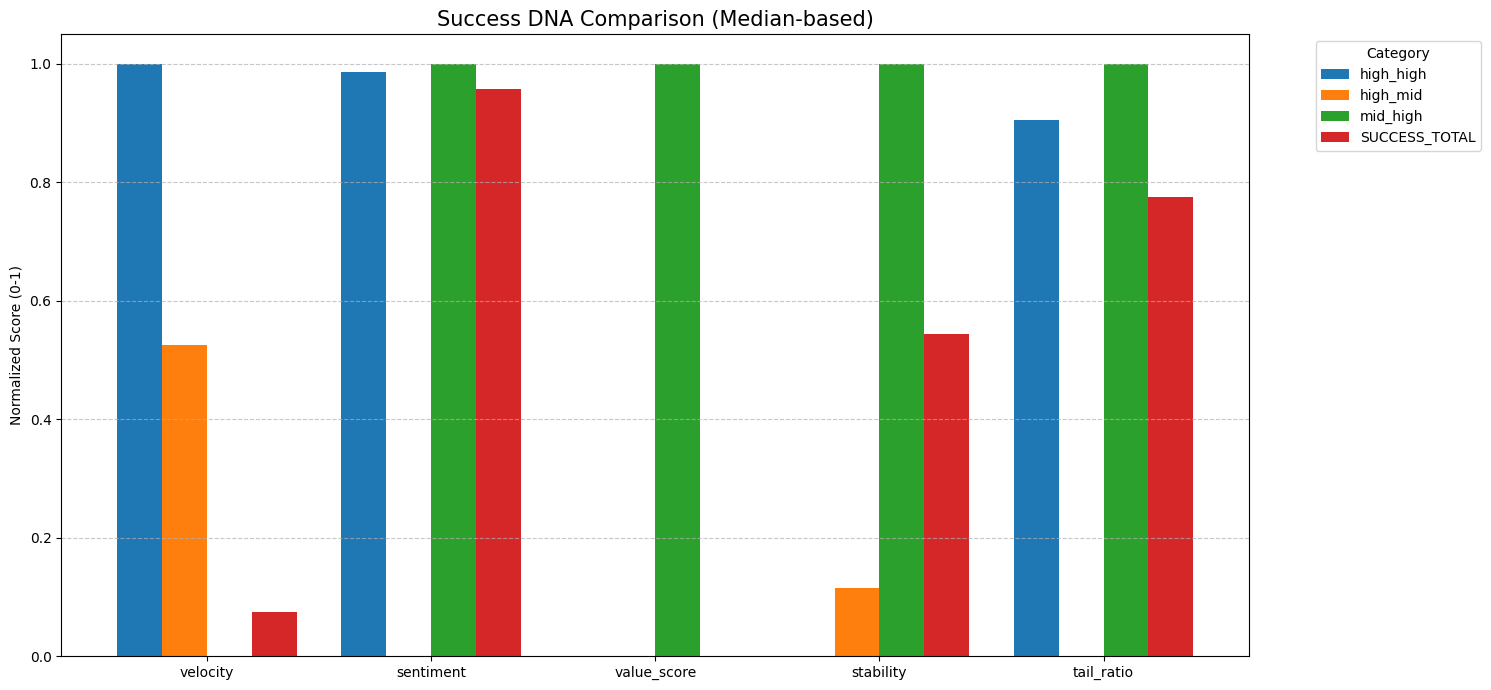

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

base_path = '../../../../data/preprocessed/'
# 파일 경로 확인 (환경에 따라 조정)
df_all = pd.read_csv(f'{base_path}steam_indie_games_graded.csv')
df_hist = pd.read_csv(f'{base_path}steam_indie_review_histogram.csv')

df_all.columns = df_all.columns.str.strip()
df_hist.columns = df_hist.columns.str.strip()

# 1. 전처리
df_all['release_date'] = pd.to_datetime(df_all['release_date'], errors='coerce')
df_hist['date'] = pd.to_datetime(df_hist['date'], errors='coerce')

if 'release_date' in df_hist.columns:
    df_hist = df_hist.drop(columns=['release_date'])
df_hist = pd.merge(df_hist, df_all[['appid', 'release_date']], on='appid', how='inner')

# 2. 지표 산출
df_all['velocity'] = df_all['total_reviews']
df_all['sentiment'] = df_all['positive_rate']
df_all['value_score'] = df_all['recommendations_total'] / (df_all['owners_lower'] + 1)

# 히스토그램 기반 안정성 및 롱테일
df_hist['daily_pos_rate'] = (df_hist['recommendations_up'] / 
                            (df_hist['recommendations_up'] + df_hist['recommendations_down'] + 1e-6)) * 100
stability_stats = df_hist.groupby('appid')['daily_pos_rate'].std().reset_index(name='stability')

df_hist['days_after_release'] = (df_hist['date'] - df_hist['release_date']).dt.days
df_hist['daily_total'] = df_hist['recommendations_up'] + df_hist['recommendations_down']

early_rev = df_hist[df_hist['days_after_release'] <= 90].groupby('appid')['daily_total'].sum().reset_index(name='rev_0_90')
mid_rev = df_hist[(df_hist['days_after_release'] > 90) & 
                  (df_hist['days_after_release'] <= 365)].groupby('appid')['daily_total'].sum().reset_index(name='rev_91_365')

tail_stats = pd.merge(early_rev, mid_rev, on='appid', how='left').fillna(0)
tail_stats['tail_ratio'] = tail_stats['rev_91_365'] / (tail_stats['rev_0_90'] + 1e-6)

# 3. 데이터 병합
final_df = pd.merge(df_all, tail_stats[['appid', 'tail_ratio']], on='appid', how='left')
final_df = pd.merge(final_df, stability_stats, on='appid', how='left')

target_grades = ['high_high', 'high_mid', 'mid_high']
features = ['velocity', 'sentiment', 'value_score', 'stability', 'tail_ratio']
success_group = final_df[final_df['performance_grade'].isin(target_grades)].copy()

# 🎯 [변경 포인트] .mean() 대신 .median() 사용
success_dna = pd.concat([
    success_group.groupby('performance_grade')[features].median(),
    pd.DataFrame(success_group[features].median()).T.rename(index={0: 'SUCCESS_TOTAL'})
])

# 4. 결과 출력 및 시각화
pd.options.display.float_format = '{:.4f}'.format
print(f"### [Success DNA] 중앙값(Median) 기반 분석 결과")
print(success_dna)

# 시각화 (중앙값 기준의 상대적 강점 비교)
plt.figure(figsize=(14, 7))
norm_dna = (success_dna - success_dna.min()) / (success_dna.max() - success_dna.min())
norm_dna.T.plot(kind='bar', figsize=(15, 7), rot=0, width=0.8)
plt.title('Success DNA Comparison (Median-based)', fontsize=15)
plt.ylabel('Normalized Score (0-1)')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### [Success DNA] owners_high 및 중앙값 기준 분석 결과
               velocity  sentiment  value_score  stability  tail_ratio
high_high     1547.0000    91.1798       0.0145    38.4652      0.4111
high_mid       867.5000    76.4131       0.0108    39.4204      0.3520
mid_high       116.0000    91.3793       0.0085    46.8062      0.4172
SUCCESS_TOTAL  223.0000    90.7407       0.0108    42.9992      0.4025


<Figure size 1400x700 with 0 Axes>

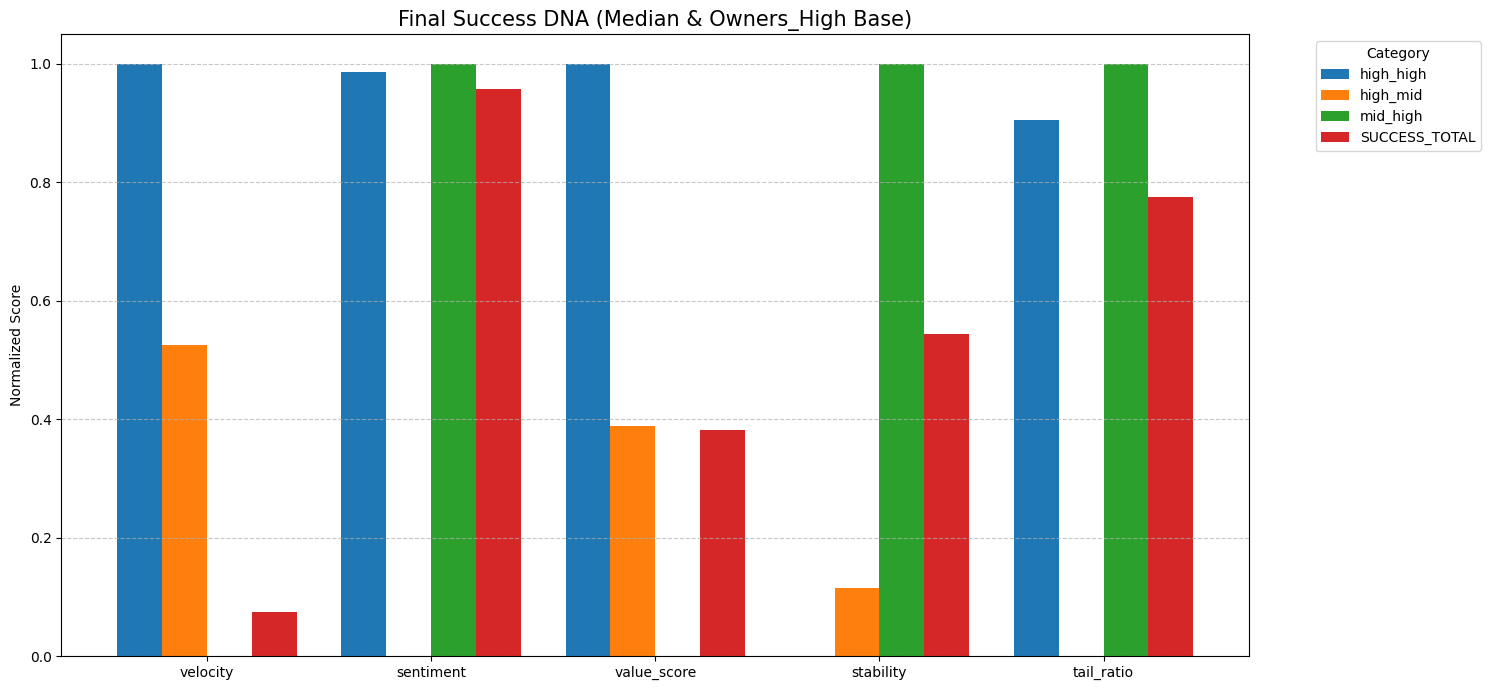

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

base_path = '../../../../data/preprocessed/'
df_all = pd.read_csv(f'{base_path}steam_indie_games_graded.csv')
df_hist = pd.read_csv(f'{base_path}steam_indie_review_histogram.csv')

df_all.columns = df_all.columns.str.strip()
df_hist.columns = df_hist.columns.str.strip()

# 1. 날짜 데이터 전처리
df_all['release_date'] = pd.to_datetime(df_all['release_date'], errors='coerce')
df_hist['date'] = pd.to_datetime(df_hist['date'], errors='coerce')

if 'release_date' in df_hist.columns:
    df_hist = df_hist.drop(columns=['release_date'])
df_hist = pd.merge(df_hist, df_all[['appid', 'release_date']], on='appid', how='inner')

# 2. 지표 산출 (owners_high 반영)
df_all['velocity'] = df_all['total_reviews']
df_all['sentiment'] = df_all['positive_rate']
# 분모를 owners_high로 변경하여 안정성 확보
df_all['value_score'] = df_all['recommendations_total'] / (df_all['owners_higher'] + 1)

# 히스토그램 기반 지표 (안정성 및 롱테일)
df_hist['daily_pos_rate'] = (df_hist['recommendations_up'] / 
                            (df_hist['recommendations_up'] + df_hist['recommendations_down'] + 1e-6)) * 100
stability_stats = df_hist.groupby('appid')['daily_pos_rate'].std().reset_index(name='stability')

df_hist['days_after_release'] = (df_hist['date'] - df_hist['release_date']).dt.days
df_hist['daily_total'] = df_hist['recommendations_up'] + df_hist['recommendations_down']

early_rev = df_hist[df_hist['days_after_release'] <= 90].groupby('appid')['daily_total'].sum().reset_index(name='rev_0_90')
mid_rev = df_hist[(df_hist['days_after_release'] > 90) & 
                  (df_hist['days_after_release'] <= 365)].groupby('appid')['daily_total'].sum().reset_index(name='rev_91_365')

tail_stats = pd.merge(early_rev, mid_rev, on='appid', how='left').fillna(0)
tail_stats['tail_ratio'] = tail_stats['rev_91_365'] / (tail_stats['rev_0_90'] + 1e-6)

# 3. 최종 데이터 병합
final_df = pd.merge(df_all, tail_stats[['appid', 'tail_ratio']], on='appid', how='left')
final_df = pd.merge(final_df, stability_stats, on='appid', how='left')

target_grades = ['high_high', 'high_mid', 'mid_high']
features = ['velocity', 'sentiment', 'value_score', 'stability', 'tail_ratio']
success_group = final_df[final_df['performance_grade'].isin(target_grades)].copy()

# 🎯 중앙값(Median) 기반 DNA 추출
success_dna = pd.concat([
    success_group.groupby('performance_grade')[features].median(),
    pd.DataFrame(success_group[features].median()).T.rename(index={0: 'SUCCESS_TOTAL'})
])

# 4. 결과 출력
pd.options.display.float_format = '{:.4f}'.format
print(f"### [Success DNA] owners_high 및 중앙값 기준 분석 결과")
print(success_dna)

# 시각화
plt.figure(figsize=(14, 7))
norm_dna = (success_dna - success_dna.min()) / (success_dna.max() - success_dna.min())
norm_dna.T.plot(kind='bar', figsize=(15, 7), rot=0, width=0.8)
plt.title('Final Success DNA (Median & Owners_High Base)', fontsize=15)
plt.ylabel('Normalized Score')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()